<a href="https://colab.research.google.com/github/natalytoriz08-png/Red-neuronal-de-clasificaci-n/blob/main/RED_NEURONAL_DE_CLASIFICACI%C3%93N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad 13 Red neuronal de clasificación**

 **¿Que es una red neuronal de clasidicación**?

Una red neuronal de clasificación es un programa de inteligencia artificial que sirve para identificar y separar datos en diferentes categorías. Funciona de manera parecida al cerebro humano, ya que aprende observando ejemplos y encontrando patrones.

Primero, la red recibe información, después la analiza y finalmente decide a qué grupo pertenece. Mientras más datos tenga para practicar, mejor aprende y más precisos son sus resultados.

Por ejemplo, una red neuronal puede:

Reconocer imágenes de animales.

*   Detectar si un correo es spam o no.
*   Identificar emociones en mensajes.
*   Reconocer voces o sonidos.
*   Ayudar en diagnósticos médicos.

Las redes neuronales son muy importantes porque permiten que las computadoras aprendan y tomen decisiones de forma automática.

1. importamos Tensorflow con import

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
datos, metadatos = tfds.load("mnist", as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.RTQEBW_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.RTQEBW_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


2. Corremos este codigo para que nos muestre todos los metadatos del set

In [3]:
metadatos

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

3. Vamos a poner ver los datos por separados segun la variable que eligimos

In [4]:
datos_entrenamiento = datos["train"]
datos_pruebas = datos["test"]

In [5]:
nombres_clases = metadatos.features["label"].names

In [6]:
#Normalizacion
#0-255 1 byte
#Transformar 0-255 0-1 (0-0, 255-1, 1275.5)

#Normalizar datos ent y pruebas con una funcion
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes = imagenes/255
  return imagenes, etiquetas

#Normalizar datos de entrenamiento con map

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#Agregar en cache
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()


4. Muestra la imagen seleccionada en pantalla junto con una barra de colores para visualizar mejor la imagen.

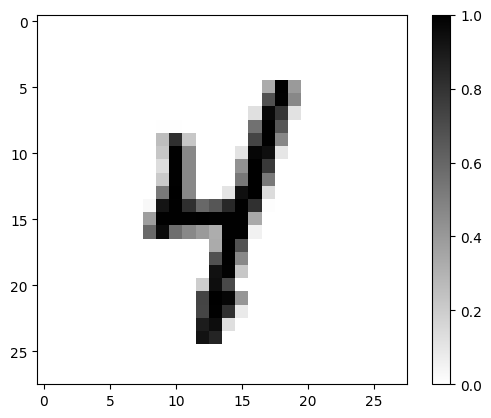

In [7]:
for imagen, etiqueta in datos_entrenamiento.take(1):
  break

import matplotlib.pyplot as plt

#Mostrarlo en pantalla
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.show()

5. Se muestra 25 imágenes del entrenamiento en una cuadrícula de 5x5 en blanco y negro.

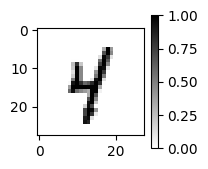

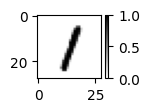

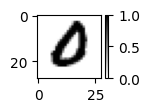

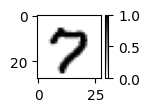

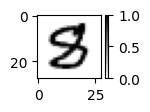

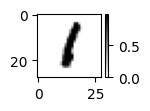

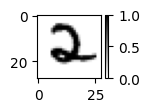

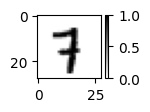

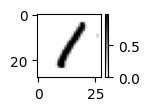

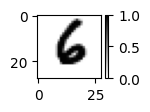

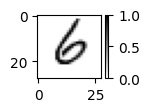

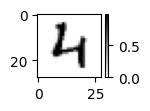

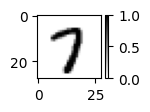

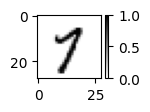

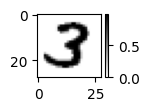

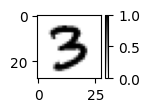

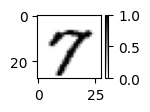

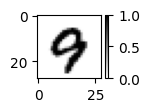

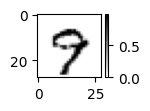

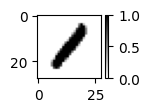

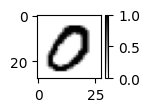

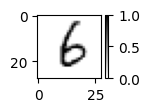

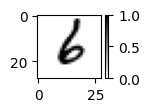

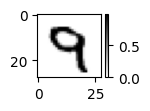

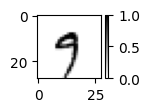

In [8]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  #Mostrarlo en pantalla
  plt.subplot(5, 5, i+1)
  plt.imshow(imagen, cmap=plt.cm.binary)
  plt.colorbar()

  plt.show()